# HistGradientBoostingClassifier — Movie Review Rating Prediction



## 1. Imports

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42

## 2. File paths

In [ ]:
DATA_PATH = "/content/processed_movie_reviews.csv"
TRAIN_MOVIES_PATH = "/content/train_movies.txt"
PREPROCESSOR_PATH = "/content/full_preprocessor.joblib"
MANIFEST_PATH = "/content/split_movies_manifest.joblib"

for p in [DATA_PATH, TRAIN_MOVIES_PATH, PREPROCESSOR_PATH, MANIFEST_PATH]:
    print(p, "->", "FOUND" if os.path.exists(p) else "MISSING")

/content/processed_movie_reviews.csv -> FOUND
/content/train_movies.txt -> FOUND
/content/full_preprocessor.joblib -> FOUND
/content/split_movies_manifest.joblib -> FOUND


## 3. Load the already-preprocessed dataset

In [ ]:
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
print(df.columns.tolist())
display(df.head())

Dataset shape: (10173, 26)
['movie_name', 'Ratings', 'word_count', 'emotion', 'cleaned_review', 'tokens_filtered', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_foreign', 'genre_history', 'genre_horror', 'genre_music', 'genre_mystery', 'genre_romance', 'genre_science_fiction', 'genre_thriller', 'genre_tv_movie', 'genre_war', 'genre_western']


,movie_name,Ratings,word_count,emotion,cleaned_review,tokens_filtered,genre_action,genre_adventure,genre_animation,genre_comedy,...,genre_history,genre_horror,genre_music,genre_mystery,genre_romance,genre_science_fiction,genre_thriller,genre_tv_movie,genre_war,genre_western
0,Waiting to Exhale,3.0,56,anticipation,it had some laughs but overall the motivation ...,laughs overall motivation incomprehensible mad...,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,Waiting to Exhale,4.0,373,anticipation,waiting to exhale waiting and waiting and wait...,waiting exhale waiting waiting waiting waiting...,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,Waiting to Exhale,4.0,45,anticipation,angela basset was good as expected but whitney...,angela basset good expected whitney range actr...,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,Waiting to Exhale,5.0,124,anticipation,the movie is okay mediocre might even be the w...,okay mediocre word say tell act angela bassett...,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,Waiting to Exhale,5.0,212,anticipation,i got an opportunity to see waiting to exhale ...,got opportunity waiting exhale second recently...,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## 4. Load `train_movies.txt` — this explicitly defines the training split

In [ ]:
with open(TRAIN_MOVIES_PATH, "r", encoding="utf-8") as f:
    movie_titles = [line.strip() for line in f if line.strip()]

train_movies = pd.DataFrame({"Movie": movie_titles})

train_movie_set = set(train_movies["Movie"])

print("Training movies listed:", len(train_movie_set))
display(train_movies.head(10))

Training movies listed: 1048


,Movie
0,+1
1,10 Rules for Sleeping Around
2,10 Things I Hate About You
3,100 Girls
4,12 Rounds
5,13 Going on 30
6,17 Again
7,18 Again!
8,1920: Evil Returns
9,21


## 5. Identify movie and target columns

In [ ]:
print("Columns in dataset:")
for i, col in enumerate(df.columns):
    print(i, repr(col))

print("\nDataset shape:", df.shape)

Columns in dataset:
0 'movie_name'
1 'Ratings'
2 'word_count'
3 'emotion'
4 'cleaned_review'
5 'tokens_filtered'
6 'genre_action'
7 'genre_adventure'
8 'genre_animation'
9 'genre_comedy'
10 'genre_crime'
11 'genre_documentary'
12 'genre_drama'
13 'genre_family'
14 'genre_fantasy'
15 'genre_foreign'
16 'genre_history'
17 'genre_horror'
18 'genre_music'
19 'genre_mystery'
20 'genre_romance'
21 'genre_science_fiction'
22 'genre_thriller'
23 'genre_tv_movie'
24 'genre_war'
25 'genre_western'

Dataset shape: (10173, 26)


## 6. Create train/test data from the supplied movie list

In [ ]:
TRAIN_MOVIES_PATH = "/content/train_movies.txt"

with open(TRAIN_MOVIES_PATH, "r", encoding="utf-8") as f:
    train_movie_set = {line.strip() for line in f if line.strip()}

# Identify the movie-title column
possible_movie_cols = [
    c for c in df.columns
    if any(word in c.lower() for word in ["movie", "title", "film"])
]

if not possible_movie_cols:
    raise ValueError(
        f"No movie-title column found. Available columns: {df.columns.tolist()}"
    )

MOVIE_COL = possible_movie_cols[0]
TARGET_COL = "Ratings"

# Clean movie titles and split the dataset
df[MOVIE_COL] = df[MOVIE_COL].astype(str).str.strip()

train_df = df[df[MOVIE_COL].isin(train_movie_set)].copy()
test_df = df[~df[MOVIE_COL].isin(train_movie_set)].copy()

print("Movie column:", MOVIE_COL)
print("Training movies listed:", len(train_movie_set))
print("Full dataset:", df.shape)
print("Training dataset:", train_df.shape)
print("Testing dataset:", test_df.shape)
print("Training movies matched:", train_df[MOVIE_COL].nunique())
print("Testing movies:", test_df[MOVIE_COL].nunique())

Movie column: movie_name
Training movies listed: 1048
Full dataset: (10173, 26)
Training dataset: (7991, 26)
Testing dataset: (2182, 26)
Training movies matched: 636
Testing movies: 174


## 7. Target distribution

In [ ]:
print("Training ratings:")
display(train_df[TARGET_COL].value_counts().sort_index())
print("Test ratings:")
display(test_df[TARGET_COL].value_counts().sort_index())

Training ratings:


,count
Ratings,
1.0,404
2.0,687
3.0,716
4.0,654
5.0,736
6.0,769
7.0,964
8.0,1000
9.0,921


Test ratings:


,count
Ratings,
1.0,120
2.0,159
3.0,202
4.0,189
5.0,165
6.0,222
7.0,273
8.0,275
9.0,247


## 8. Select existing processed features

In [ ]:
genre_cols = [c for c in train_df.columns if c.startswith("genre_")]
structured_cols = [c for c in ["word_count", "emotion"] if c in train_df.columns] + genre_cols
assert "tokens_filtered" in train_df.columns
assert structured_cols
print("Structured features:", structured_cols)
print("Number of structured features:", len(structured_cols))

Structured features: ['word_count', 'emotion', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_foreign', 'genre_history', 'genre_horror', 'genre_music', 'genre_mystery', 'genre_romance', 'genre_science_fiction', 'genre_thriller', 'genre_tv_movie', 'genre_war', 'genre_western']
Number of structured features: 22


## 9. Prepare structured features

In [ ]:
X_train_struct = train_df[structured_cols].apply(pd.to_numeric, errors="coerce")
X_test_struct = test_df[structured_cols].apply(pd.to_numeric, errors="coerce")

medians = X_train_struct.median()
X_train_struct = X_train_struct.fillna(medians).fillna(0)
X_test_struct = X_test_struct.fillna(medians).fillna(0)

y_train = train_df[TARGET_COL].astype(int)
y_test = test_df[TARGET_COL].astype(int)

print(X_train_struct.shape, X_test_struct.shape)

(7991, 22) (2182, 22)


## 10. Hyperparameter tuning setup

In [ ]:
PARAM_GRID = {
    "learning_rate": [0.05, 0.10],
    "max_iter": [100, 200],
    "max_leaf_nodes": [15, 31],
    "min_samples_leaf": [20, 40]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Combinations:", 16)
print("CV folds:", 5)

Combinations: 16
CV folds: 5


## 11. Model 1 — HGB with structured features + GridSearchCV

In [ ]:
grid_struct = GridSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    PARAM_GRID, scoring="f1_macro", cv=cv, n_jobs=-1, refit=True, verbose=1
)
grid_struct.fit(X_train_struct, y_train)
print("Best parameters:", grid_struct.best_params_)
print("Best CV Macro F1:", grid_struct.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'learning_rate': 0.1, 'max_iter': 100, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}
Best CV Macro F1: 0.1407700151310016


## 12. Use the existing `tokens_filtered`

In [ ]:
train_text = train_df["tokens_filtered"].fillna("").astype(str)
test_text = test_df["tokens_filtered"].fillna("").astype(str)
print(train_text.iloc[0][:500])

laughs overall motivation incomprehensible mad men cheating sleep sorts married men hypocritical lives messed messed stupid choices empathy women


## 13. Model 2 — Word TF-IDF + SVD + structured features

In [ ]:
word_vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=10000, sublinear_tf=True)
X_train_word_tfidf = word_vectorizer.fit_transform(train_text)
X_test_word_tfidf = word_vectorizer.transform(test_text)

word_svd = TruncatedSVD(n_components=min(100, max(2, X_train_word_tfidf.shape[1]-1)), random_state=RANDOM_STATE)
X_train_word_svd = word_svd.fit_transform(X_train_word_tfidf)
X_test_word_svd = word_svd.transform(X_test_word_tfidf)

X_train_word = np.hstack([X_train_word_svd, X_train_struct.to_numpy()])
X_test_word = np.hstack([X_test_word_svd, X_test_struct.to_numpy()])
print("TF-IDF:", X_train_word_tfidf.shape)
print("Final:", X_train_word.shape)

TF-IDF: (7991, 10000)
Final: (7991, 122)


## 14. Tune Model 2 — GridSearchCV

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold


WORD_PARAM_GRID = {
    "learning_rate": [0.05, 0.10],
    "max_iter": [100],
    "max_leaf_nodes": [15, 31],
    "min_samples_leaf": [20]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

hgb_word = HistGradientBoostingClassifier(
    random_state=42
)

grid_word = GridSearchCV(
    estimator=hgb_word,
    param_grid=WORD_PARAM_GRID,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_word.fit(X_train_word, y_train)

print("\nBest parameters:", grid_word.best_params_)
print("Best CV Macro F1:", grid_word.best_score_)

best_word_model = grid_word.best_estimator_

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best parameters: {'learning_rate': 0.05, 'max_iter': 100, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}
Best CV Macro F1: 0.24939838538762182


## 15. Model 3 — Character TF-IDF + SVD + structured features

In [ ]:
char_vectorizer = TfidfVectorizer(analyzer="char", ngram_range=(3,5), min_df=2, max_features=10000, sublinear_tf=True)
X_train_char_tfidf = char_vectorizer.fit_transform(train_text)
X_test_char_tfidf = char_vectorizer.transform(test_text)

char_svd = TruncatedSVD(n_components=min(100, max(2, X_train_char_tfidf.shape[1]-1)), random_state=RANDOM_STATE)
X_train_char_svd = char_svd.fit_transform(X_train_char_tfidf)
X_test_char_svd = char_svd.transform(X_test_char_tfidf)

X_train_char = np.hstack([X_train_char_svd, X_train_struct.to_numpy()])
X_test_char = np.hstack([X_test_char_svd, X_test_struct.to_numpy()])
print("TF-IDF:", X_train_char_tfidf.shape)
print("Final:", X_train_char.shape)

TF-IDF: (7991, 10000)
Final: (7991, 122)


## 16. Tune Model 3 — GridSearchCV

In [ ]:
grid_char = GridSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    PARAM_GRID, scoring="f1_macro", cv=cv, n_jobs=-1, refit=True, verbose=1
)
grid_char.fit(X_train_char, y_train)
print("Best parameters:", grid_char.best_params_)
print("Best CV Macro F1:", grid_char.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'learning_rate': 0.05, 'max_iter': 200, 'max_leaf_nodes': 15, 'min_samples_leaf': 40}
Best CV Macro F1: 0.2401717022037043


## 17. Compare the three tuned HGB variants

In [30]:
models = {
    "HGB - Structured": (grid_struct, X_test_struct),
    "HGB - Word TF-IDF + SVD": (grid_word, X_test_word),
    "HGB - Character TF-IDF + SVD": (grid_char, X_test_char)
}
rows = []
for name, (grid, X) in models.items():
    pred = grid.best_estimator_.predict(X)
    rows.append({
        "Model": name,
        "CV Macro F1": grid.best_score_,
        "Test Accuracy": accuracy_score(y_test, pred),
        "Test Macro Precision": precision_score(y_test, pred, average="macro", zero_division=0),
        "Test Macro Recall": recall_score(y_test, pred, average="macro", zero_division=0),
        "Test Macro F1": f1_score(y_test, pred, average="macro", zero_division=0),
        "Test Weighted F1": f1_score(y_test, pred, average="weighted", zero_division=0)
    })
results_df = pd.DataFrame(rows).sort_values("CV Macro F1", ascending=False).reset_index(drop=True)
display(results_df)

,Model,CV Macro F1,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1,Test Weighted F1
0,HGB - Word TF-IDF + SVD,0.249398,0.258937,0.252560,0.248551,0.244932,0.247821
1,HGB - Character TF-IDF + SVD,0.240172,0.243813,0.245470,0.235252,0.234842,0.236076
2,HGB - Structured,0.140770,0.128781,0.114218,0.112603,0.109928,0.120801


## 18. Select the best variant using cross-validation

In [31]:
best_name = results_df.loc[0, "Model"]
best_grid = models[best_name][0]
best_model = best_grid.best_estimator_
print("Selected:", best_name)
print("Best parameters:", best_grid.best_params_)
print("Best CV Macro F1:", best_grid.best_score_)

Selected: HGB - Word TF-IDF + SVD
Best parameters: {'learning_rate': 0.05, 'max_iter': 100, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}
Best CV Macro F1: 0.24939838538762182


## 19. Final evaluation on the held-out test movies

In [32]:
best_X_test = models[best_name][1]
pred = best_model.predict(best_X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Macro Precision:", precision_score(y_test, pred, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_test, pred, average="macro", zero_division=0))
print("Macro F1:", f1_score(y_test, pred, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_test, pred, average="weighted", zero_division=0))

Accuracy: 0.2589367552703941
Macro Precision: 0.25256032377944143
Macro Recall: 0.24855082575614101
Macro F1: 0.2449317474401537
Weighted F1: 0.24782148556686884


## 20. Classification report

In [33]:
print(classification_report(y_test, pred, digits=4, zero_division=0))

              precision    recall  f1-score   support

           1     0.5882    0.4167    0.4878       120
           2     0.2356    0.3333    0.2760       159
           3     0.2100    0.2079    0.2090       202
           4     0.1694    0.1111    0.1342       189
           5     0.1083    0.0788    0.0912       165
           6     0.1884    0.1171    0.1444       222
           7     0.2177    0.2344    0.2257       273
           8     0.1943    0.1745    0.1839       275
           9     0.2107    0.2389    0.2239       247
          10     0.4030    0.5727    0.4731       330

    accuracy                         0.2589      2182
   macro avg     0.2526    0.2486    0.2449      2182
weighted avg     0.2475    0.2589    0.2478      2182



## 21. Confusion matrix

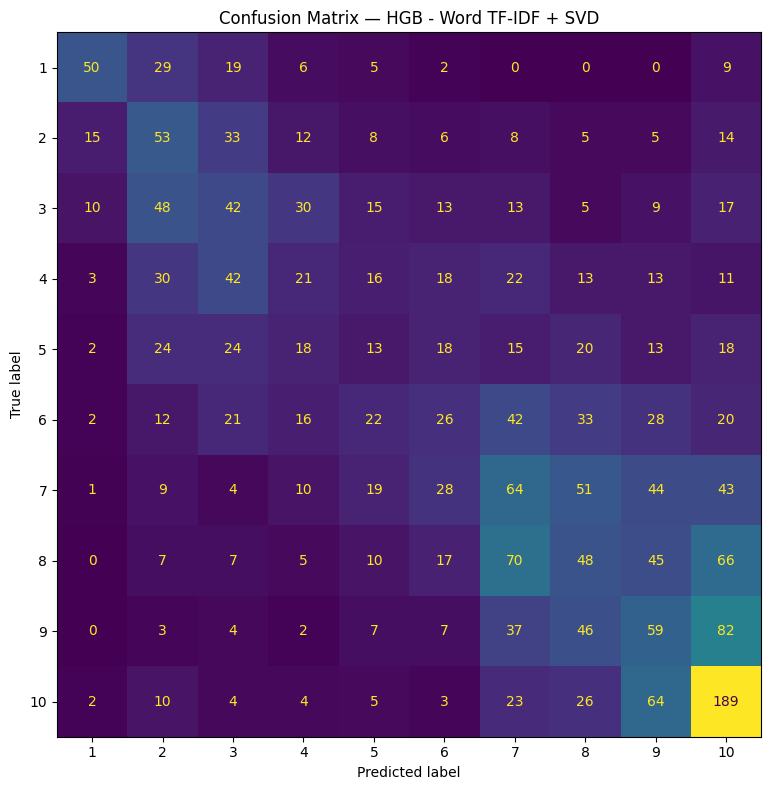

In [34]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(10,8))
disp.plot(ax=ax, values_format="d", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

## 22. Save the trained model and feature artifacts

In [35]:
out = "/content/hgb_movie_model"
os.makedirs(out, exist_ok=True)

joblib.dump(best_model, f"{out}/hist_gradient_boosting_best_model.joblib")

artifacts = {
    "model_name": best_name,
    "movie_column": MOVIE_COL,
    "target_column": TARGET_COL,
    "structured_columns": structured_cols,
    "structured_medians": medians.to_dict()
}
if best_name == "HGB - Word TF-IDF + SVD":
    artifacts["tfidf_vectorizer"] = word_vectorizer
    artifacts["svd"] = word_svd
elif best_name == "HGB - Character TF-IDF + SVD":
    artifacts["tfidf_vectorizer"] = char_vectorizer
    artifacts["svd"] = char_svd

joblib.dump(artifacts, f"{out}/hgb_feature_artifacts.joblib")
results_df.to_csv(f"{out}/hgb_model_comparison.csv", index=False)

print("Saved:")
for f in os.listdir(out):
    print("-", f)

Saved:
- hgb_model_comparison.csv
- hgb_feature_artifacts.joblib
- hist_gradient_boosting_best_model.joblib
